In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

In [ ]:
def load_img(path_to_img, max_dim=512):
    img = tf.io.read_file(path_to_img)
    img = tf.image.decode_image(img, channels=3)
    img = tf.image.convert_image_dtype(img, tf.float32)

    shape = tf.cast(tf.shape(img)[:-1], tf.float32)
    long_dim = max(shape)
    scale = max_dim / long_dim

    new_shape = tf.cast(shape * scale, tf.int32)
    img = tf.image.resize(img, new_shape)
    return img[tf.newaxis, :]

In [ ]:
def get_vgg_layers(layer_names):
    vgg = tf.keras.applications.VGG19(include_top=False, weights='imagenet')
    vgg.trainable = False
    outputs = [vgg.get_layer(name).output for name in layer_names]
    return tf.keras.Model([vgg.input], outputs)

In [ ]:
class StyleContentModel(tf.keras.models.Model):
    def __init__(self, style_layers, content_layers):
        super().__init__()
        self.vgg = get_vgg_layers(style_layers + content_layers)
        self.style_layers = style_layers
        self.content_layers = content_layers
        self.num_style_layers = len(style_layers)
        self.vgg.trainable = False

    def call(self, inputs):
        inputs = inputs * 255.0
        preprocessed_input = tf.keras.applications.vgg19.preprocess_input(inputs)
        outputs = self.vgg(preprocessed_input)
        style_outputs, content_outputs = (outputs[:self.num_style_layers],
                                          outputs[self.num_style_layers:])

        # Calculate Gram matrices for style
        style_outputs = [self.gram_matrix(style_output)
                        for style_output in style_outputs]

        content_dict = {content_name: value for content_name, value
                       in zip(self.content_layers, content_outputs)}
        style_dict = {style_name: value for style_name, value
                     in zip(self.style_layers, style_outputs)}

        return {'content': content_dict, 'style': style_dict}

    def gram_matrix(self, input_tensor):
        result = tf.linalg.einsum('bijc,bijd->bcd', input_tensor, input_tensor)
        input_shape = tf.shape(input_tensor)
        num_locations = tf.cast(input_shape[1] * input_shape[2], tf.float32)
        return result / num_locations

In [ ]:
def train_style_transfer(content_path, style_path, epochs=10, steps_per_epoch=100):
    # Load images
    content_image = load_img(content_path)
    style_image = load_img(style_path)

    # Initialize with content image (or noise)
    generated_image = tf.Variable(content_image)

    # Define layers for style/content extraction
    content_layers = ['block5_conv2']
    style_layers = ['block1_conv1', 'block2_conv1', 'block3_conv1',
                    'block4_conv1', 'block5_conv1']

    extractor = StyleContentModel(style_layers, content_layers)

    # Get target features
    style_targets = extractor(style_image)['style']
    content_targets = extractor(content_image)['content']

    # Optimizer
    opt = tf.optimizers.Adam(learning_rate=0.02)

    # Loss weights
    style_weight = 1e-2
    content_weight = 1e4

    # Training loop
    for epoch in range(epochs):
        for step in range(steps_per_epoch):
            with tf.GradientTape() as tape:
                outputs = extractor(generated_image)
                content_outputs = outputs['content']
                style_outputs = outputs['style']

                # Content loss
                content_loss = tf.add_n([
                    tf.reduce_mean((content_outputs[name] - content_targets[name])**2)
                    for name in content_outputs.keys()
                ])
                content_loss *= content_weight

                # Style loss
                style_loss = tf.add_n([
                    tf.reduce_mean((style_outputs[name] - style_targets[name])**2)
                    for name in style_outputs.keys()
                ])
                style_loss *= style_weight

                total_loss = content_loss + style_loss

            # Apply gradients
            grad = tape.gradient(total_loss, generated_image)
            opt.apply_gradients([(grad, generated_image)])

            # Clipping
            generated_image.assign(tf.clip_by_value(generated_image, 0.0, 1.0))

        print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss.numpy():.2f}")

    return generated_image

In [ ]:
content_path = "/content/originall.jpg"
style_path = "/content/style.jpg"

In [ ]:
result = train_style_transfer(content_path, style_path, epochs=5, steps_per_epoch=50)

80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5, Loss: 30078608.00
Epoch 2/5, Loss: 17161496.00
Epoch 3/5, Loss: 13699300.00
Epoch 4/5, Loss: 11967656.00
Epoch 5/5, Loss: 11568893.00


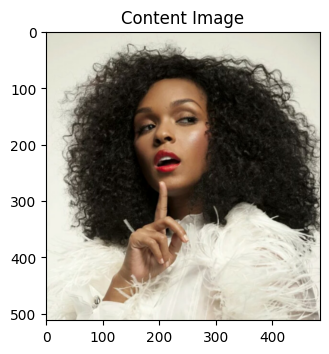

In [ ]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.title('Content Image')
plt.imshow(load_img(content_path)[0])

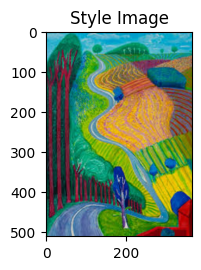

In [ ]:
plt.subplot(1, 3, 2)
plt.title('Style Image')
plt.imshow(load_img(style_path)[0])

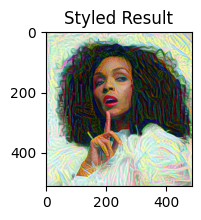

In [ ]:
plt.subplot(1, 3, 3)
plt.title('Styled Result')
plt.imshow(result[0].numpy())
plt.show()